# DEER - hw2

In [1]:
!pip install scikit-learn seaborn tqdm pandas numpy matplotlib scipy -q


In [2]:
import json, math, random, warnings
from collections import defaultdict, Counter
from dataclasses import dataclass
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import HashingVectorizer
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import f1_score, precision_score, recall_score
from scipy.sparse import hstack as sp_hstack

In [3]:
SEED = 42
TRAIN_SIZE = 3000
TEST_SIZE  = 500
N_EPOCHS = 50
CW = 2

random.seed(SEED)
np.random.seed(SEED)

LABEL2ID = {
    'O':0,
    'B-PER':1, 'I-PER':2,
    'B-ORG':3, 'I-ORG':4,
    'B-LOC':5, 'I-LOC':6,
    'B-MISC':7,'I-MISC':8,
}
ID2LABEL      = {v: k for k, v in LABEL2ID.items()}
ENTITY_TYPES  = ['PER', 'ORG', 'LOC', 'MISC']
METHODS       = ['Baseline', 'DEER v1 (Sample Weights)', 'DEER v2 (Feature Injection)']

In [4]:
import subprocess, os
if not os.path.exists('deer'):
    subprocess.run(['git', 'clone', 'https://github.com/bflashcp3f/deer.git'], check=True)

if not os.path.exists('deer/data'):
    subprocess.run(['tar', '-xzf', 'deer/deer_data.tar.gz', '-C', 'deer/'], check=True)

for f in os.listdir('deer/data'):
    print(f"  deer/data/{f}/")

  deer/data/ontonotes/
  deer/data/bc2gm/
  deer/data/conll03/
  deer/data/ncbi/
  deer/data/tweetner7/


In [5]:
DATA_DIR = 'deer/data/conll03'

raw_all_train, raw_test = [], []

with open(f'{DATA_DIR}/train.jsonl') as fh:
    for line in fh:
        raw_all_train.append(json.loads(line))

with open(f'{DATA_DIR}/test_sample_1000.jsonl') as fh:
    for line in fh:
        raw_test.append(json.loads(line))

In [6]:
_rng = random.Random(SEED)
_rng.shuffle(raw_all_train)
raw_train = raw_all_train[:TRAIN_SIZE]
raw_test  = raw_test[:TEST_SIZE]

print(f'Train: {len(raw_train)},  Test: {len(raw_test)}')

ec = Counter(ent['type'] for ex in raw_train for ent in ex.get('ent_list', []))
print('Типы сущностей (train):')
total_ents = sum(ec.values())
for etype in ENTITY_TYPES:
    cnt = ec.get(etype, 0)
    print(f'  {etype:5s}: {cnt:5d} ({cnt/total_ents*100:5.1f}%)')

Train: 3000,  Test: 500
Типы сущностей (train):
  PER  :  1404 ( 27.9%)
  ORG  :  1337 ( 26.6%)
  LOC  :  1508 ( 30.0%)
  MISC :   777 ( 15.5%)


In [7]:
def to_bio(example: dict) -> Tuple[List[str], List[str]]:
    tokens = example['tokens']
    bio = ['O'] * len(tokens)
    for ent in example.get('ent_list', []):
        s, e = ent['token_idx']
        bio[s] = 'B-' + ent['type']
        for i in range(s + 1, e + 1):
            bio[i] = 'I-' + ent['type']
    return tokens, bio


def baseline_features(tokens: List[str], i: int) -> str:
    tok   = tokens[i]
    prev1 = tokens[i - 1] if i > 0             else '<S>'
    prev2 = tokens[i - 2] if i > 1             else '<S2>'
    next1 = tokens[i + 1] if i < len(tokens)-1 else '</S>'
    next2 = tokens[i + 2] if i < len(tokens)-2 else '</S2>'
    return ' '.join([
        tok.lower(),
        tok[:2].lower(), tok[:3].lower(),
        tok[-2:].lower(), tok[-3:].lower(),
        f'upper={tok.isupper()}',
        f'title={tok.istitle()}',
        f'digit={tok.isdigit()}',
        f'len={min(len(tok), 10)}',
        f'p1={prev1.lower()}', f'p2={prev2.lower()}',
        f'n1={next1.lower()}', f'n2={next2.lower()}',
        f'p1title={prev1.istitle()}', f'n1title={next1.istitle()}',
    ])


BASE_VEC = HashingVectorizer(n_features=2**17, alternate_sign=False, norm='l2')
_toks, _bio = to_bio(raw_train[0])


In [8]:
@dataclass
class TokStat:
    entity:  int = 0
    context: int = 0
    other:   int = 0

    @property
    def total(self) -> int:
        return self.entity + self.context + self.other

    @property
    def p_entity(self) -> float:
        return self.entity / max(self.total, 1)

    @property
    def p_context(self) -> float:
        return self.context / max(self.total, 1)

    @property
    def p_other(self) -> float:
        return self.other / max(self.total, 1)


class DEERLabelStats:
    def __init__(self, context_window: int = CW,
                 we: float = 2.0, wc: float = 1.2, wo: float = 0.05):
        self.cw = context_window
        self.we, self.wc, self.wo = we, wc, wo
        self._stats : Dict[str, TokStat] = defaultdict(TokStat)
        self._seen  : set                = set()

    def fit(self, dataset: List[dict]) -> 'DEERLabelStats':
        for ex in dataset:
            toks, bio = to_bio(ex)
            n = len(toks)
            ent_pos = {i for i, b in enumerate(bio) if b != 'O'}
            ctx_pos = {
                j
                for p in ent_pos
                for d in range(-self.cw, self.cw + 1)
                if 0 <= (j := p + d) < n and j not in ent_pos
            }
            for i, tok in enumerate(toks):
                t = tok.lower()
                self._seen.add(t)
                st = self._stats[t]
                if i in ent_pos:   st.entity  += 1
                elif i in ctx_pos: st.context += 1
                else:              st.other   += 1
        return self
    def weight(self, token: str) -> float:
        t = token.lower()
        if t not in self._seen:
            return 1.5
        st = self._stats[t]
        return self.we * st.p_entity + self.wc * st.p_context + self.wo * st.p_other

    def p_entity(self, token: str)  -> float:
        return self._stats.get(token.lower(), TokStat()).p_entity

    def p_context(self, token: str) -> float:
        return self._stats.get(token.lower(), TokStat()).p_context

    def is_unseen(self, token: str) -> bool:
        return token.lower() not in self._seen

    @property
    def vocab_size(self) -> int:
        return len(self._stats)



In [9]:
deer_stats = DEERLabelStats()
deer_stats.fit(raw_train)

print(f'Словарь: {deer_stats.vocab_size} уникальных токенов')
print(f'Примеры весов W(t):')
for tok in ['Belarus', 'the', 'in', 'Moscow', 'Germany', 'NEWTOKEN_XYZ']:
    print(f'{tok:18s}  W={deer_stats.weight(tok):.4f}  '
          f'P(ent)={deer_stats.p_entity(tok):.3f}  '
          f'P(ctx)={deer_stats.p_context(tok):.3f}  '
          f'unseen={deer_stats.is_unseen(tok)}')


Словарь: 9241 уникальных токенов
Примеры весов W(t):
Belarus             W=2.0000  P(ent)=1.000  P(ctx)=0.000  unseen=False
the                 W=0.4506  P(ent)=0.009  P(ctx)=0.332  unseen=False
in                  W=0.5364  P(ent)=0.001  P(ctx)=0.421  unseen=False
Moscow              W=2.0000  P(ent)=1.000  P(ctx)=0.000  unseen=False
Germany             W=2.0000  P(ent)=1.000  P(ctx)=0.000  unseen=False
NEWTOKEN_XYZ        W=1.5000  P(ent)=0.000  P(ctx)=0.000  unseen=True


#### DEER v1

LR + токен взвешен по W(t) из DEER


In [10]:
deer_v1_weight_fn = lambda tok: deer_stats.weight(tok)
categories = {
    'High-entity  (Germany, London, FIFA)': ['Germany','London','FIFA','Manchester','Reuters'],
    'Context-only (in, at, the)':           ['in','at','the','from','to'],
    'Low-signal   (said, has, is)':         ['said','has','is','was','were'],
}
for cat_name, examples in categories.items():
    weights = [deer_stats.weight(t) for t in examples]
    print(f'{cat_name}')
    for tok, w in zip(examples, weights):
        print(f' {tok:14s}  W={w:.4f}')


High-entity  (Germany, London, FIFA)
 Germany         W=2.0000
 London          W=2.0000
 FIFA            W=1.5000
 Manchester      W=2.0000
 Reuters         W=2.0000
Context-only (in, at, the)
 in              W=0.5364
 at              W=0.5457
 the             W=0.4506
 from            W=0.5286
 to              W=0.3540
Low-signal   (said, has, is)
 said            W=0.5836
 has             W=0.5441
 is              W=0.4170
 was             W=0.3504
 were            W=0.2340


## DEER v2 — Numeric Feature

числовые признаки DEER непосредственно к feature-вектору каждого токена:
- P(entity), P(context), W(t) — для самого токена и соседей +-1
- бинарные флаги pe_high, pc_high, unseen


In [11]:
DEER_VEC = DictVectorizer(sparse=True)

def extract_deer_numeric(dataset: List[dict]) -> List[dict]:
    rows = []
    for ex in dataset:
        toks, _ = to_bio(ex)
        for i, tok in enumerate(toks):
            prev = toks[i - 1] if i > 0             else '<S>'
            nxt  = toks[i + 1] if i < len(toks) - 1 else '</S>'

            feats = {
                'pe_self':  deer_stats.p_entity(tok),
                'pc_self':  deer_stats.p_context(tok),
                'w_self':   deer_stats.weight(tok),
                'unseen':   float(deer_stats.is_unseen(tok)),
                'pe_prev':  deer_stats.p_entity(prev),
                'pc_prev':  deer_stats.p_context(prev),
                'pe_next':  deer_stats.p_entity(nxt),
                'pc_next':  deer_stats.p_context(nxt),
                'pe_hi':    float(deer_stats.p_entity(tok)  > 0.4),
                'pc_hi':    float(deer_stats.p_context(tok) > 0.3),
                'ctx_pe_max': max(deer_stats.p_entity(prev), deer_stats.p_entity(nxt)),
            }
            rows.append(feats)
    return rows

train_deer_rows = extract_deer_numeric(raw_train)
DEER_VEC.fit(train_deer_rows)
test_deer_rows  = extract_deer_numeric(raw_test)

print(f'DEER-признаки: {len(DEER_VEC.feature_names_)} числовых фич')
print(f'Имена: {list(DEER_VEC.feature_names_)}')
print('токен "Germany" (контекст: "west" ... "said"):')
sample_row = extract_deer_numeric([{
    'tokens': ['west', 'Germany', 'said'],
    'ent_list': [{'name':'Germany','type':'LOC','token_idx':[1,1]}]
}])[1]
for k, v in sample_row.items():
    print(f'  {k:5s}: {v:.4f}')


DEER-признаки: 11 числовых фич
Имена: ['ctx_pe_max', 'pc_hi', 'pc_next', 'pc_prev', 'pc_self', 'pe_hi', 'pe_next', 'pe_prev', 'pe_self', 'unseen', 'w_self']
токен "Germany" (контекст: "west" ... "said"):
  pe_self: 1.0000
  pc_self: 0.0000
  w_self: 2.0000
  unseen: 0.0000
  pe_prev: 0.8500
  pc_prev: 0.0500
  pe_next: 0.0000
  pc_next: 0.4640
  pe_hi: 1.0000
  pc_hi: 0.0000
  ctx_pe_max: 0.8500


In [12]:
def build_matrices(dataset: List[dict], weight_fn=None):
    feat_strings, labels, weights = [], [], []
    for ex in dataset:
        toks, bio = to_bio(ex)
        for i, tok in enumerate(toks):
            feat_strings.append(baseline_features(toks, i))
            labels.append(LABEL2ID.get(bio[i], 0))
            if weight_fn:
                weights.append(weight_fn(tok))
    X = BASE_VEC.transform(feat_strings)
    y = np.array(labels)
    w = np.array(weights) if weights else None
    return X, y, w


def build_v2_matrices(dataset: List[dict]):
    feat_strings, labels = [], []
    for ex in dataset:
        toks, bio = to_bio(ex)
        for i in range(len(toks)):
            feat_strings.append(baseline_features(toks, i))
            labels.append(LABEL2ID.get(bio[i], 0))
    X_base = BASE_VEC.transform(feat_strings)

    deer_rows = extract_deer_numeric(dataset)
    X_deer    = DEER_VEC.transform(deer_rows)

    X = sp_hstack([X_base, X_deer])
    y = np.array(labels)
    return X, y


def entity_only_f1(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    mask = y_true != LABEL2ID['O']
    if mask.sum() == 0:
        return 0.0
    return f1_score(y_true[mask], y_pred[mask],
                    average='macro', zero_division=0)


def per_type_scores(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, Dict[str, float]]:
    result = {}
    for etype in ENTITY_TYPES:
        ids  = [LABEL2ID[f'B-{etype}'], LABEL2ID[f'I-{etype}']]
        mask = np.isin(y_true, ids) | np.isin(y_pred, ids)
        if mask.sum() == 0:
            result[etype] = {'P': 0.0, 'R': 0.0, 'F1': 0.0}
            continue
        yt = np.isin(y_true, ids).astype(int)[mask]
        yp = np.isin(y_pred, ids).astype(int)[mask]
        result[etype] = {
            'P':  round(precision_score(yt, yp, zero_division=0), 4),
            'R':  round(recall_score(yt, yp, zero_division=0), 4),
            'F1': round(f1_score(yt, yp, zero_division=0), 4),
        }
    return result



In [13]:
X_te_base, y_te, _ = build_matrices(raw_test)
X_te_v2,   _       = build_v2_matrices(raw_test)
y_test_ref = y_te

test_X = {
    'Baseline':                  X_te_base,
    'DEER v1 (Sample Weights)':  X_te_base,
    'DEER v2 (Feature Injection)': X_te_v2,
}

history      : Dict[str, Dict] = {m: {'macro':[],'micro':[],'entity':[]} for m in METHODS}
final_models : Dict = {}
final_preds  : Dict = {}

epoch_sizes = [TRAIN_SIZE // N_EPOCHS * (k + 1) for k in range(N_EPOCHS)]
print(f'Размеры субвыборок по эпохам: {epoch_sizes}')
print()


Размеры субвыборок по эпохам: [60, 120, 180, 240, 300, 360, 420, 480, 540, 600, 660, 720, 780, 840, 900, 960, 1020, 1080, 1140, 1200, 1260, 1320, 1380, 1440, 1500, 1560, 1620, 1680, 1740, 1800, 1860, 1920, 1980, 2040, 2100, 2160, 2220, 2280, 2340, 2400, 2460, 2520, 2580, 2640, 2700, 2760, 2820, 2880, 2940, 3000]



In [14]:
for method in METHODS:
    print(f' {method}')

    for epoch_idx, ep_size in enumerate(epoch_sizes):
        subset = raw_train[:ep_size]

        if method == 'Baseline':
            X_tr, y_tr, w_tr = build_matrices(subset, weight_fn=None)
        elif method == 'DEER v1 (Sample Weights)':
            X_tr, y_tr, w_tr = build_matrices(subset, weight_fn=deer_v1_weight_fn)
        else:
            X_tr, y_tr       = build_v2_matrices(subset)
            w_tr             = None

        clf = LogisticRegression(
            max_iter=600, C=0.8, solver='saga',
            n_jobs=-1, random_state=SEED
        )
        fit_kwargs = {'sample_weight': w_tr} if w_tr is not None else {}
        clf.fit(X_tr, y_tr, **fit_kwargs)

        y_pred = clf.predict(test_X[method])
        macro  = round(f1_score(y_test_ref, y_pred, average='macro',  zero_division=0), 4)
        micro  = round(f1_score(y_test_ref, y_pred, average='micro',  zero_division=0), 4)
        entity = round(entity_only_f1(y_test_ref, y_pred), 4)

        history[method]['macro'].append(macro)
        history[method]['micro'].append(micro)
        history[method]['entity'].append(entity)

        print(f'  Epoch {epoch_idx+1}/{N_EPOCHS}  '
              f'n={ep_size:5d}  '
              f'F1-macro={macro:.4f}  '
              f'F1-micro={micro:.4f}  '
              f'F1-entity={entity:.4f}')

        if epoch_idx == N_EPOCHS - 1:
            final_models[method] = clf
            final_preds[method]  = y_pred

    print()


 Baseline
  Epoch 1/50  n=   60  F1-macro=0.1109  F1-micro=0.8242  F1-entity=0.0117
  Epoch 2/50  n=  120  F1-macro=0.1135  F1-micro=0.8240  F1-entity=0.0145
  Epoch 3/50  n=  180  F1-macro=0.1124  F1-micro=0.8236  F1-entity=0.0133
  Epoch 4/50  n=  240  F1-macro=0.1134  F1-micro=0.8237  F1-entity=0.0145
  Epoch 5/50  n=  300  F1-macro=0.1168  F1-micro=0.8240  F1-entity=0.0180
  Epoch 6/50  n=  360  F1-macro=0.1174  F1-micro=0.8242  F1-entity=0.0187
  Epoch 7/50  n=  420  F1-macro=0.1182  F1-micro=0.8243  F1-entity=0.0194
  Epoch 8/50  n=  480  F1-macro=0.1196  F1-micro=0.8242  F1-entity=0.0208
  Epoch 9/50  n=  540  F1-macro=0.1245  F1-micro=0.8248  F1-entity=0.0260
  Epoch 10/50  n=  600  F1-macro=0.1289  F1-micro=0.8254  F1-entity=0.0305
  Epoch 11/50  n=  660  F1-macro=0.1492  F1-micro=0.8265  F1-entity=0.0507
  Epoch 12/50  n=  720  F1-macro=0.1732  F1-micro=0.8272  F1-entity=0.0746
  Epoch 13/50  n=  780  F1-macro=0.1781  F1-micro=0.8280  F1-entity=0.0797
  Epoch 14/50  n=  840  

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


  Epoch 1/50  n=   60  F1-macro=0.2382  F1-micro=0.8537  F1-entity=0.1354


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


  Epoch 2/50  n=  120  F1-macro=0.2579  F1-micro=0.8611  F1-entity=0.1546


...

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


  Epoch 48/50  n= 2880  F1-macro=0.5114  F1-micro=0.8900  F1-entity=0.4195


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


  Epoch 49/50  n= 2940  F1-macro=0.5116  F1-micro=0.8896  F1-entity=0.4200
  Epoch 50/50  n= 3000  F1-macro=0.5088  F1-micro=0.8899  F1-entity=0.4186



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [28]:
PALETTE = {'Baseline': 'skyblue',
                 'DEER v1 (Sample Weights)': 'purple',
                 'DEER v2 (Feature Injection)': 'brown'}
COLORS  = [PALETTE[m] for m in METHODS]

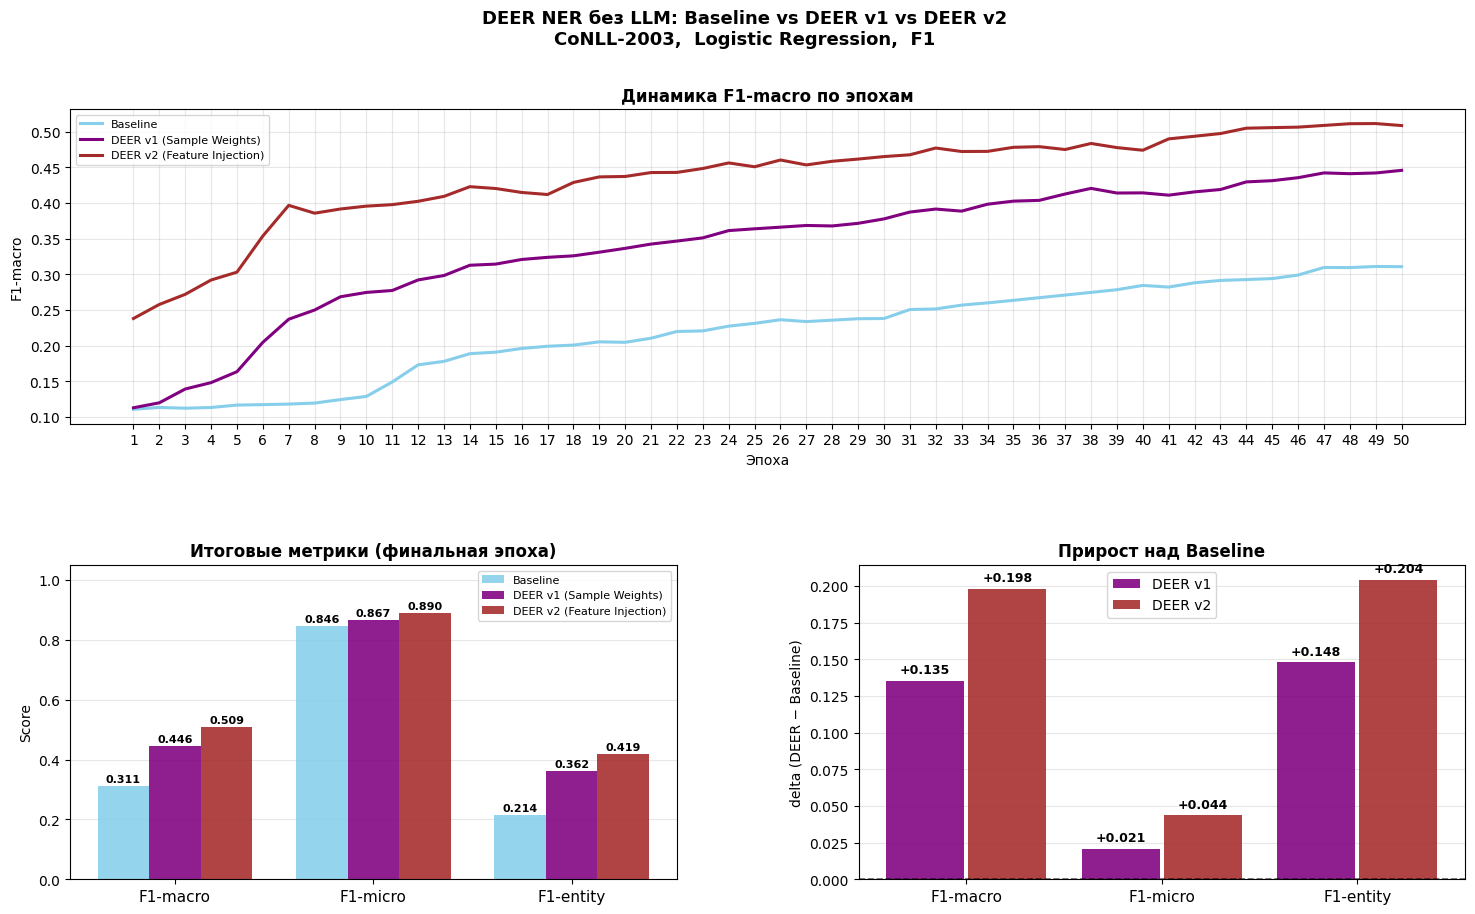

In [29]:
fig = plt.figure(figsize=(18, 10))
fig.suptitle(
    'DEER NER без LLM: Baseline vs DEER v1 vs DEER v2\n'
    'CoNLL-2003,  Logistic Regression,  F1',
    fontsize=13, fontweight='bold'
)

gs = fig.add_gridspec(2, 2, hspace=0.45, wspace=0.3)

ax  = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])

for m, col in zip(METHODS, COLORS):
    ax.plot(EPOCHS, history[m]['macro'],color=col, lw=2.2, ms=8, label=m)
ax.set_xlabel('Эпоха')
ax.set_ylabel('F1-macro')
ax.set_title('Динамика F1-macro по эпохам', fontweight='bold')
ax.set_xticks(EPOCHS)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
ax.set_axisbelow(True)

x = np.arange(len(metric_labels))
w = 0.26
for j, (m, col) in enumerate(zip(METHODS, COLORS)):
    vals = [history[m][mk][-1] for mk in metric_keys]
    bars = ax2.bar(x + j * w, vals, w, label=m, color=col, alpha=0.88)
    for bar, v in zip(bars, vals):
        ax2.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.005,
                 f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax2.set_xticks(x + w)
ax2.set_xticklabels(metric_labels, fontsize=11)
ax2.set_ylim(0, 1.05)
ax2.set_ylabel('Score')
ax2.set_title('Итоговые метрики (финальная эпоха)', fontweight='bold')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3, axis='y')
ax2.set_axisbelow(True)

base_vals  = np.array([history['Baseline'][mk][-1] for mk in metric_keys])
deer1_vals = np.array([history['DEER v1 (Sample Weights)'][mk][-1] for mk in metric_keys])
deer2_vals = np.array([history['DEER v2 (Feature Injection)'][mk][-1] for mk in metric_keys])

g1 = deer1_vals - base_vals
g2 = deer2_vals - base_vals
x3 = np.arange(len(metric_labels))

b1 = ax3.bar(x3 - 0.21, g1, 0.40, label='DEER v1', color=COLORS[1], alpha=0.88)
b2 = ax3.bar(x3 + 0.21, g2, 0.40, label='DEER v2', color=COLORS[2], alpha=0.88)

for bar, v in list(zip(b1, g1)) + list(zip(b2, g2)):
    yoff = 0.003 if v >= 0 else -0.010
    ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + yoff,
             f'{v:+.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax3.axhline(0, color='black', lw=1.2, ls='--', alpha=0.6)
ax3.set_xticks(x3)
ax3.set_xticklabels(metric_labels, fontsize=11)
ax3.set_ylabel('delta (DEER − Baseline)')
ax3.set_title('Прирост над Baseline', fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(alpha=0.3, axis='y')
ax3.set_axisbelow(True)

plt.show()

In [31]:
pt_scores = {m: per_type_scores(y_test_ref, final_preds[m]) for m in METHODS}

rows = []
for m in METHODS:
    h    = history[m]
    base = history['Baseline']
    row  = {
    'Method':    m,
    'F1-macro':  h['macro'][-1],
    'F1-micro':  h['micro'][-1],
    'F1-entity': h['entity'][-1],
    'delta macro':  round(h['macro'][-1]  - base['macro'][-1],  4),
    'delta entity': round(h['entity'][-1] - base['entity'][-1], 4),
}
    for et in ENTITY_TYPES:
        row[f'{et}'] = pt_scores[m][et]['F1']
    rows.append(row)

cols_main = ['Method','F1-macro','F1-micro','F1-entity','delta macro','delta entity']
print(df[cols_main].to_string(index=False))
print('  F1 по типам сущностей:')
print(df[['Method'] + ENTITY_TYPES].to_string(index=False))


                     Method  F1-macro  F1-micro  F1-entity  delta macro  delta entity
                   Baseline    0.3109    0.8462     0.2145       0.0000        0.0000
   DEER v1 (Sample Weights)    0.4460    0.8668     0.3625       0.1351        0.1480
DEER v2 (Feature Injection)    0.5088    0.8899     0.4186       0.1979        0.2041
  F1 по типам сущностей:
                     Method    PER    ORG    LOC   MISC
                   Baseline 0.3090 0.2283 0.3203 0.3000
   DEER v1 (Sample Weights) 0.5407 0.4059 0.4948 0.5570
DEER v2 (Feature Injection) 0.4283 0.4698 0.5971 0.5952


Базовый классификатор без каких-либо улучшений показал слабый результат — F1-macro 0.31, F1-entity 0.21.

В целом ок - модель обучается на несбалансированных данных и плохо справляется с редкими сущностями.
DEER v1 (взвешивание примеров) заметно улучшил ситуацию:
F1-macro вырос до 0.45 (+0.14), F1-entity до 0.36 (+0.15). Особенно хорошо модель стала находить людей (PER: 0.54) и разные (MISC: 0.56).


DEER v2 (добавление признаков) показал лучший общий результат: F1-macro 0.51 (+0.20), F1-entity 0.42 (+0.20). Модель лучше всех справилась с локациями (LOC: 0.60) и MISC (0.60), хотя на людях (PER: 0.43) проиграла v1.
Итог: оба варианта DEER стабильно превосходят basekine
DEER v2 в целом лучше, но для задач, где важно находить именно людей, предпочтительнее DEER v1.